In [ ]:
import awswrangler as wr

import mlflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Variables de entorno
%env AWS_ACCESS_KEY_ID=minio   
%env AWS_SECRET_ACCESS_KEY=minio123 
%env MLFLOW_S3_ENDPOINT_URL=http://localhost:9000
%env AWS_ENDPOINT_URL_S3=http://localhost:9000

# Comparación de modelos y búsqueda de hiperparámetros

Tomamos el dataset ya procesado de S3 bucket y vamos a comparar algunos modelos para determinar cuál es el mejor y qué hiperparámetros usar

In [ ]:
mlflow_server = "http://localhost:5001"
#mlflow_server = "http://192.168.0.21:5001"

mlflow.set_tracking_uri(mlflow_server)

In [ ]:
# Cargamos los datos para realizar nuestro estudio.
X_train =  wr.s3.read_csv("s3://data/final/train/dielectron_X_train.csv")
y_train =  wr.s3.read_csv("s3://data/final/train/dielectron_y_train.csv")

X_test =  wr.s3.read_csv("s3://data/final/test/dielectron_X_test.csv")
y_test =  wr.s3.read_csv("s3://data/final/test/dielectron_y_test.csv")

In [ ]:
import kagglehub
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import optuna

from mlflow.models import infer_signature
from mlflow_aux import get_or_create_experiment

from optuna_aux import champion_callback, objective

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


optuna.logging.set_verbosity(optuna.logging.ERROR)


In [ ]:
# Creemos el experimento
experiment_id = get_or_create_experiment("Dielectron")
print(experiment_id)

run_name_parent = "best_hyperparam_"  + datetime.datetime.today().strftime('%Y/%m/%d-%H:%M:%S"')

1


### Descripción de las variables

| Variable | Descripción |
|----------|-------------|
| `E1`, `E2` | Energía de cada electrón (GeV) |
| `px1`, `py1`, `pz1` | Componentes del momento del electrón 1 (GeV/c) |
| `px2`, `py2`, `pz2` | Componentes del momento del electrón 2 (GeV/c) |
| `pt1`, `pt2` | Momento transversal de cada electrón (GeV/c) |
| `eta1`, `eta2` | Pseudorapidez (ángulo polar logarítmico) |
| `phi1`, `phi2` | Ángulo azimutal (radianes) |
| `Q1`, `Q2` | Carga eléctrica de cada electrón (+1 o -1) |
| `M` | **Masa invariante del par** (GeV/c²) — variable objetivo |

In [ ]:
# Escalado (necesario para regresión lineal y Ridge)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

### Candidatos evaluados

| Algoritmo | Ventajas | Desventajas |
|-----------|----------|-------------|
| **Regresión Lineal** | Simple, interpretable | No captura no-linealidades |
| **Ridge Regression** | Regularización L2, estable | Aún lineal |
| **Árbol de Decisión** | No-lineal, interpretable | Sobreajuste fácil |
| **Random Forest** | Robusto, no-lineal, bajo sobreajuste | Mayor costo computacional |
| **Gradient Boosting** | Muy alto rendimiento, no-lineal | Hiperparámetros sensibles |


In [ ]:
modelos = {
    'Regresión Lineal':   LinearRegression(),
    'Ridge':              Ridge(alpha=1.0),
    'Árbol de Decisión':  DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest':      RandomForestRegressor(n_estimators=100, max_depth=15,
                                                random_state=42, n_jobs=-1),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                                    learning_rate=0.1, random_state=42),
}

resultados = []

for nombre, modelo in modelos.items():
    print(f"Entrenando: {nombre}...", end=' ')

    # Usar datos escalados para modelos lineales
    if 'Lineal' in nombre or 'Ridge' in nombre:
        modelo.fit(X_train_sc, y_train)
        y_pred = modelo.predict(X_test_sc)
    else:
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    resultados.append({
        'Modelo': nombre,
        'RMSE (GeV)': round(rmse, 4),
        'MAE (GeV)':  round(mae, 4),
        'R²':         round(r2, 6)
    })
    print(f"RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.6f}")

df_resultados = pd.DataFrame(resultados).sort_values('RMSE (GeV)')
print("\n===== RESUMEN COMPARATIVO =====")
print(df_resultados.to_string(index=False))

Entrenando: Regresión Lineal... RMSE=19.5717, MAE=14.2250, R²=0.401339
Entrenando: Ridge... RMSE=19.5717, MAE=14.2250, R²=0.401339
Entrenando: Árbol de Decisión... RMSE=11.4668, MAE=8.3433, R²=0.794504
Entrenando: Random Forest... RMSE=6.5250, MAE=4.6630, R²=0.933460
Entrenando: Gradient Boosting... RMSE=4.1642, MAE=2.9192, R²=0.972898

===== RESUMEN COMPARATIVO =====
           Modelo  RMSE (GeV)  MAE (GeV)       R²
Gradient Boosting      4.1642     2.9192 0.972898
    Random Forest      6.5250     4.6630 0.933460
Árbol de Decisión     11.4668     8.3433 0.794504
            Ridge     19.5717    14.2250 0.401339
 Regresión Lineal     19.5717    14.2250 0.401339


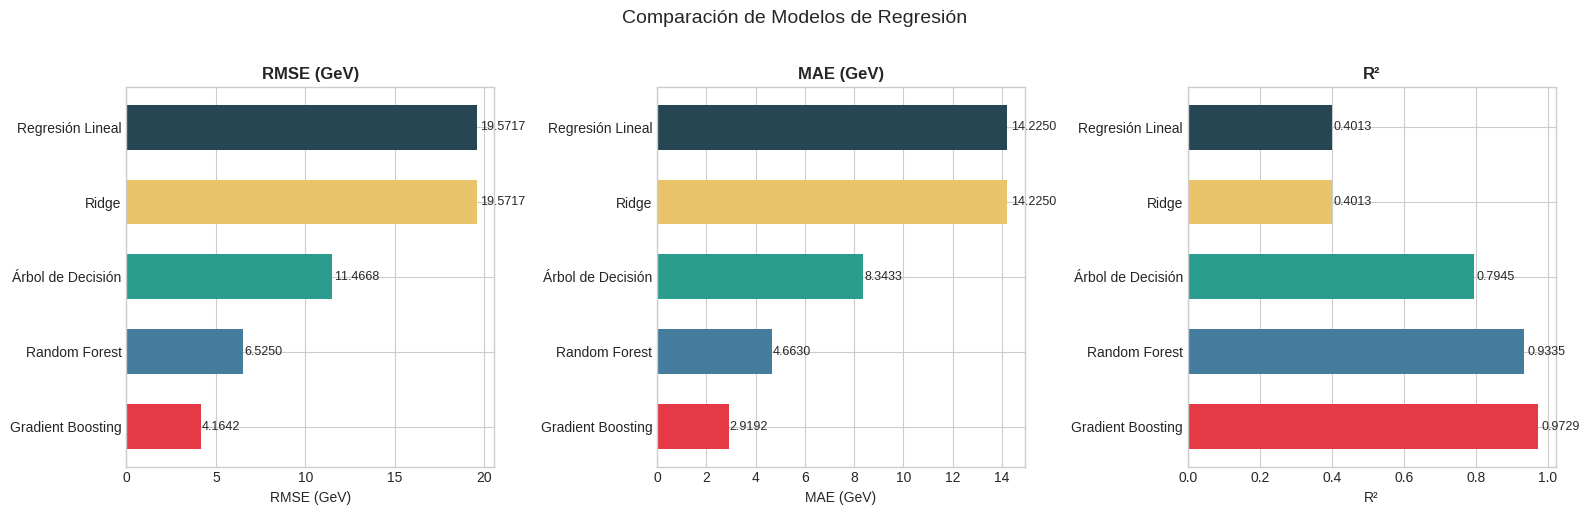

In [ ]:
# Visualización comparativa de métricas
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metricas = ['RMSE (GeV)', 'MAE (GeV)', 'R²']
colores_barra = [COLORS[i % len(COLORS)] for i in range(len(df_resultados))]

for i, metrica in enumerate(metricas):
    bars = axes[i].barh(df_resultados['Modelo'], df_resultados[metrica],
                        color=colores_barra, edgecolor='none', height=0.6)
    axes[i].set_title(metrica, fontsize=12, fontweight='bold')
    axes[i].set_xlabel(metrica)
    # Etiquetas en barras
    for bar, val in zip(bars, df_resultados[metrica]):
        axes[i].text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                     f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Comparación de Modelos de Regresión', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretación del gráfico: Comparación de modelos de regresión

Este gráfico compara el desempeño de los distintos modelos utilizados para aproximar la masa invariante. La comparación se realiza mediante tres métricas: RMSE, MAE y R².

El RMSE mide el error promedio del modelo dando más peso a los errores grandes. Cuanto menor sea, mejor. El MAE mide el error promedio de manera más directa y también se interpreta mejor cuando es menor. El R² indica qué tan bien el modelo logra explicar la variación de la masa invariante; en este caso, cuanto más alto sea, mejor.

El gráfico permite ver rápidamente qué modelos tienen menor error y cuáles logran representar mejor la relación entre las variables físicas y la masa. Esta comparación es importante porque no alcanza con elegir un algoritmo por intuición: es necesario observar cuál funciona mejor sobre los datos concretos del problema.


## 8. Análisis detallado del modelo elegido: Gradient Boosting

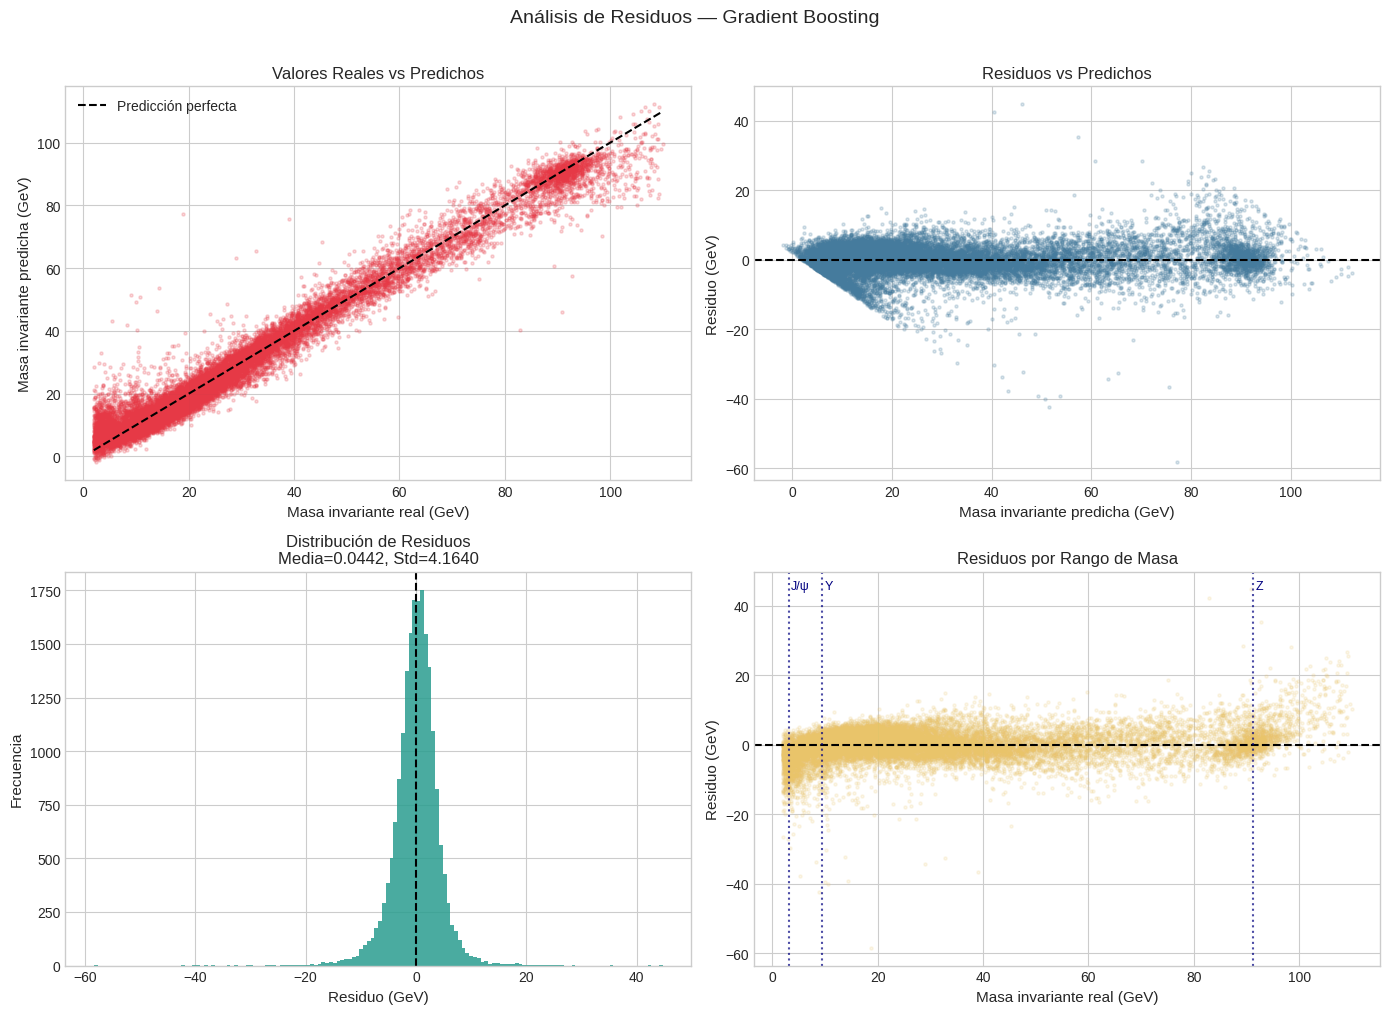

In [ ]:
# Recuperar el modelo GB ya entrenado
gb_model = modelos['Gradient Boosting']
y_pred_gb = gb_model.predict(X_test)
residuos  = y_test.values - y_pred_gb

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Predicho vs Real
axes[0,0].scatter(y_test, y_pred_gb, alpha=0.2, s=5, color=COLORS[0])
lim = [y_test.min(), y_test.max()]
axes[0,0].plot(lim, lim, 'k--', linewidth=1.5, label='Predicción perfecta')
axes[0,0].set_xlabel('Masa invariante real (GeV)', fontsize=11)
axes[0,0].set_ylabel('Masa invariante predicha (GeV)', fontsize=11)
axes[0,0].set_title('Valores Reales vs Predichos', fontsize=12)
axes[0,0].legend()

# 2. Residuos vs Predichos
axes[0,1].scatter(y_pred_gb, residuos, alpha=0.2, s=5, color=COLORS[1])
axes[0,1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[0,1].set_xlabel('Masa invariante predicha (GeV)', fontsize=11)
axes[0,1].set_ylabel('Residuo (GeV)', fontsize=11)
axes[0,1].set_title('Residuos vs Predichos', fontsize=12)

# 3. Distribución de residuos
axes[1,0].hist(residuos, bins=150, color=COLORS[2], alpha=0.85, edgecolor='none')
axes[1,0].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[1,0].set_xlabel('Residuo (GeV)', fontsize=11)
axes[1,0].set_ylabel('Frecuencia', fontsize=11)
axes[1,0].set_title(f'Distribución de Residuos\nMedia={residuos.mean():.4f}, Std={residuos.std():.4f}', fontsize=12)

# 4. Residuos en función de la masa real (para detectar sesgos por rango)
axes[1,1].scatter(y_test, residuos, alpha=0.15, s=5, color=COLORS[3])
axes[1,1].axhline(0, color='black', linewidth=1.5, linestyle='--')
for nombre, masa in {'J/ψ': 3.1, 'Υ': 9.5, 'Z': 91.2}.items():
    axes[1,1].axvline(masa, color='navy', linestyle=':', alpha=0.7)
    axes[1,1].text(masa+0.5, axes[1,1].get_ylim()[1]*0.9, nombre, fontsize=9, color='navy')
axes[1,1].set_xlabel('Masa invariante real (GeV)', fontsize=11)
axes[1,1].set_ylabel('Residuo (GeV)', fontsize=11)
axes[1,1].set_title('Residuos por Rango de Masa', fontsize=12)

plt.suptitle('Análisis de Residuos — Gradient Boosting', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('analisis_residuos_gb.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretación del gráfico: Valores reales, predicciones y residuos

Este conjunto de gráficos permite analizar con más detalle cómo se comporta el modelo seleccionado. No alcanza con saber que el modelo tiene un buen resultado global; también es necesario observar en qué casos acierta mejor y en cuáles se equivoca más.

El gráfico de valores reales frente a valores predichos muestra si las predicciones se acercan a los valores reales de masa invariante. Cuando los puntos se ubican cerca de la línea diagonal, significa que el modelo predice con mayor precisión.

El gráfico de residuos permite ver los errores del modelo. Un residuo es la diferencia entre el valor real y el valor predicho. Si los errores se distribuyen alrededor de cero sin un patrón muy marcado, el modelo tiene un comportamiento más equilibrado. En cambio, si los errores se concentran o crecen en alguna zona, puede indicar que el modelo tiene más dificultad en ciertos rangos de masa.

La distribución de residuos ayuda a observar si la mayoría de los errores son pequeños o si existen errores grandes en algunos casos. El análisis del error según la masa permite detectar si el modelo funciona mejor en algunos rangos que en otros. Esto es especialmente importante en este problema, porque ciertas regiones de masa pueden tener relevancia física particular.


## 9. Importancia de Features

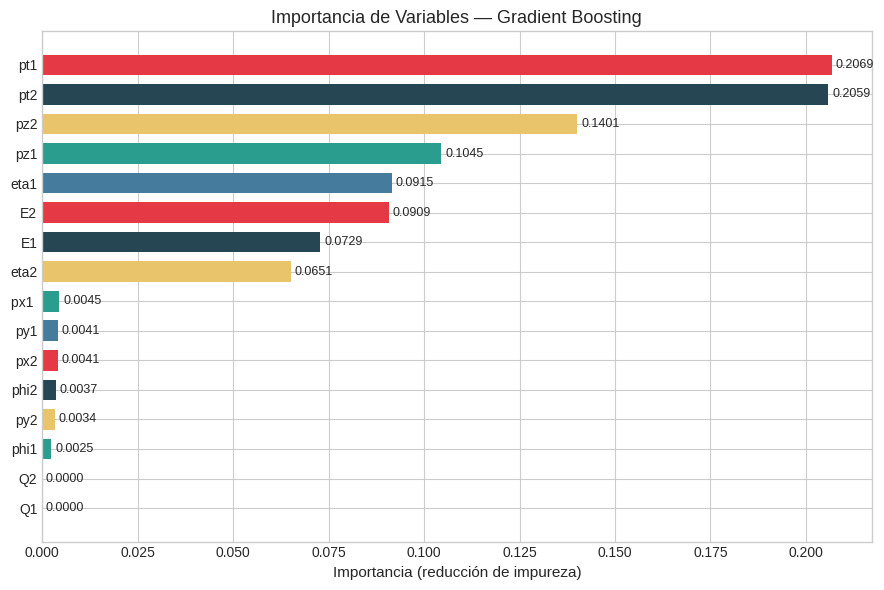


Las 5 variables más importantes:
pt1     0.206852
pt2     0.205867
pz2     0.140125
pz1     0.104518
eta1    0.091504
dtype: float64


In [ ]:
# Importancia intrínseca del Gradient Boosting
importancias = pd.Series(gb_model.feature_importances_, index=FEATURES)
importancias = importancias.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importancias.index, importancias.values,
               color=[COLORS[i % len(COLORS)] for i in range(len(importancias))],
               edgecolor='none', height=0.7)
ax.set_xlabel('Importancia (reducción de impureza)', fontsize=11)
ax.set_title('Importancia de Variables — Gradient Boosting', fontsize=13)

for bar, val in zip(bars, importancias.values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nLas 5 variables más importantes:")
print(importancias.sort_values(ascending=False).head(5))

### Interpretación del gráfico: Importancia de variables

Este gráfico muestra qué variables fueron más utilizadas por el modelo Gradient Boosting para realizar sus predicciones. En términos simples, indica cuáles columnas aportaron más información para aproximar la masa invariante.
Es razonable que aparezcan como importantes variables relacionadas con la energía y el movimiento de los electrones, porque la masa invariante depende justamente de cómo se combinan esas magnitudes físicas.

El gráfico muestra que el modelo Gradient Boosting no utiliza todas las variables con la misma intensidad. Las variables con mayor importancia son principalmente aquellas asociadas al movimiento de los electrones, especialmente el momento transversal pt1 y pt2, las componentes del momento pz1 y pz2, las variables angulares eta1 y eta2, y la energía E1 y E2. Esto es coherente con el problema físico, porque la masa invariante depende de cómo se combinan la energía y el momento de las partículas.

De todos modos, esta interpretación debe hacerse con cuidado. Que una variable tenga alta importancia para el modelo no significa necesariamente que sea la causa física directa del resultado. Significa que, dentro del modelo entrenado, esa variable ayudó a reducir errores y mejorar las predicciones. Por eso, este gráfico debe leerse como una herramienta para interpretar el comportamiento del modelo, no como una demostración física definitiva.


## 10. Busqueda de Hiperparámetros

In [ ]:
import optuna
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Definir subconjunto para búsqueda rápida (30% de los datos)
X_train_sub, _, y_train_sub, _ = train_test_split(X_train, y_train, train_size=0.3, random_state=42)

# 2. Definir la función objetivo
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.2),
        'random_state': 42
    }
    model = GradientBoostingRegressor(**params)
    # Usamos el subconjunto y cv=2 para máxima velocidad
    score = cross_val_score(model, X_train_sub, y_train_sub, cv=2, scoring='r2', n_jobs=-1)
    return score.mean()

# 3. Ejecutar la optimización
optuna.logging.set_verbosity(optuna.logging.ERROR)
study = optuna.create_study(direction='maximize')
print("Iniciando búsqueda de hiperparámetros...")
study.optimize(objective, n_trials=10)

# 4. Mostrar mejores resultados y re-entrenar con el 100% de los datos
print(f"Mejor R² en búsqueda: {study.best_value:.4f}")
print(f"Mejores parámetros: {study.best_params}")

print("Entrenando modelo final con el set completo...")
best_gb = GradientBoostingRegressor(**study.best_params, random_state=42)
best_gb.fit(X_train, y_train)
modelos['Gradient Boosting'] = best_gb

# 5. Calcular métricas finales sobre el conjunto de test
y_pred_final = best_gb.predict(X_test)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
mae_final = mean_absolute_error(y_test, y_pred_final)
r2_final = r2_score(y_test, y_pred_final)

print("\n===== MÉTRICAS DEL MODELO RESULTANTE DE LA BÚSQUEDA CON OPTUNA SOBRE X_test =====")
print(f"RMSE: {rmse_final:.4f} GeV/c²")
print(f"MAE:  {mae_final:.4f} GeV/c²")
print(f"R²:   {r2_final:.6f}")

Iniciando búsqueda de hiperparámetros...
Mejor R² en búsqueda: 0.9610
Mejores parámetros: {'n_estimators': 155, 'max_depth': 6, 'learning_rate': 0.18727396588439948}
Entrenando modelo final con el set completo...

===== MÉTRICAS DEL MODELO RESULTANTE DE LA BÚSQUEDA CON OPTUNA SOBRE X_test =====
RMSE: 3.4424 GeV/c²
MAE:  2.3802 GeV/c²
R²:   0.981480


In [ ]:
# 5. Calcular métricas finales sobre el conjunto de test
y_pred_final = best_gb.predict(X_test)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
mae_final = mean_absolute_error(y_test, y_pred_final)
r2_final = r2_score(y_test, y_pred_final)

print("\n===== MÉTRICAS FINALES (Modelo Optimizado sobre X_test) =====")
print(f"RMSE: {rmse_final:.4f} GeV/c²")
print(f"MAE:  {mae_final:.4f} GeV/c²")
print(f"R²:   {r2_final:.6f}")


===== MÉTRICAS FINALES (Modelo Optimizado sobre X_test) =====
RMSE: 3.4424 GeV/c²
MAE:  2.3802 GeV/c²
R²:   0.981480


## 11. Métricas finales y validación cruzada

In [ ]:
# Métricas en conjunto de prueba
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb  = mean_absolute_error(y_test, y_pred_gb)
r2_gb   = r2_score(y_test, y_pred_gb)
mape_gb = np.mean(np.abs(residuos / y_test.values)) * 100

print("=" * 50)
print("   MÉTRICAS — GRADIENT BOOSTING (conjunto test)")
print("=" * 50)
print(f"  RMSE  : {rmse_gb:.4f} GeV/c²")
print(f"  MAE   : {mae_gb:.4f} GeV/c²")
print(f"  R²    : {r2_gb:.6f}")
print(f"  MAPE  : {mape_gb:.2f} %")
print("=" * 50)

   MÉTRICAS — GRADIENT BOOSTING (conjunto test)
  RMSE  : 4.1642 GeV/c²
  MAE   : 2.9192 GeV/c²
  R²    : 0.972898
  MAPE  : 23.67 %


### Justificación de las métricas de evaluación

Como el objetivo del trabajo es aproximar la masa invariante, el problema se plantea como una tarea de regresión. Por ese motivo, se utilizan métricas adecuadas para evaluar predicciones numéricas continuas.

El MAE permite interpretar el error promedio de manera directa, porque indica cuánto se alejan, en promedio, las predicciones del valor real de masa. El RMSE también mide el error, pero penaliza con mayor intensidad los errores grandes, por lo que resulta útil para detectar si el modelo comete equivocaciones importantes en algunos eventos. El R², por su parte, permite observar qué proporción de la variabilidad de la masa invariante logra explicar el modelo.
Estas métricas se complementan con gráficos de valores reales frente a valores predichos y análisis de residuos. Esto es importante porque no alcanza con saber si el modelo tiene buen rendimiento global: también es necesario observar si los errores se distribuyen de manera razonable o si se concentran en determinados rangos de masa.



In [ ]:
# Validación cruzada (5-fold) sobre todo el dataset
# Usamos un modelo con menos estimadores para que sea factible en CV
gb_cv = GradientBoostingRegressor(n_estimators=100, max_depth=5,
                                   learning_rate=0.1, random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse = np.sqrt(-cross_val_score(gb_cv, X, y, cv=kf,
                                    scoring='neg_mean_squared_error', n_jobs=-1))
cv_r2   = cross_val_score(gb_cv, X, y, cv=kf, scoring='r2', n_jobs=-1)

print("Validación cruzada (5-fold) — Gradient Boosting:")
print(f"  RMSE por fold : {cv_rmse.round(4)}")
print(f"  RMSE promedio : {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f} GeV/c²")
print(f"  R² promedio   : {cv_r2.mean():.6f} ± {cv_r2.std():.6f}")

Validación cruzada (5-fold) — Gradient Boosting:
  RMSE por fold : [6.0863 6.5661 6.4164 6.5625 6.2966]
  RMSE promedio : 6.3856 ± 0.1802 GeV/c²
  R² promedio   : 0.936014 ± 0.003668


### Validación cruzada como control de estabilidad

La validación cruzada se utiliza como una comprobación adicional de estabilidad. Permite evaluar si el desempeño del modelo se mantiene al cambiar la partición de los datos, evitando depender únicamente de una única división entre entrenamiento y prueba.

En conjunto, estas métricas y gráficos son suficientes para evaluar el rendimiento del modelo en el marco de este trabajo.

## 12. Interpretación física de los resultados

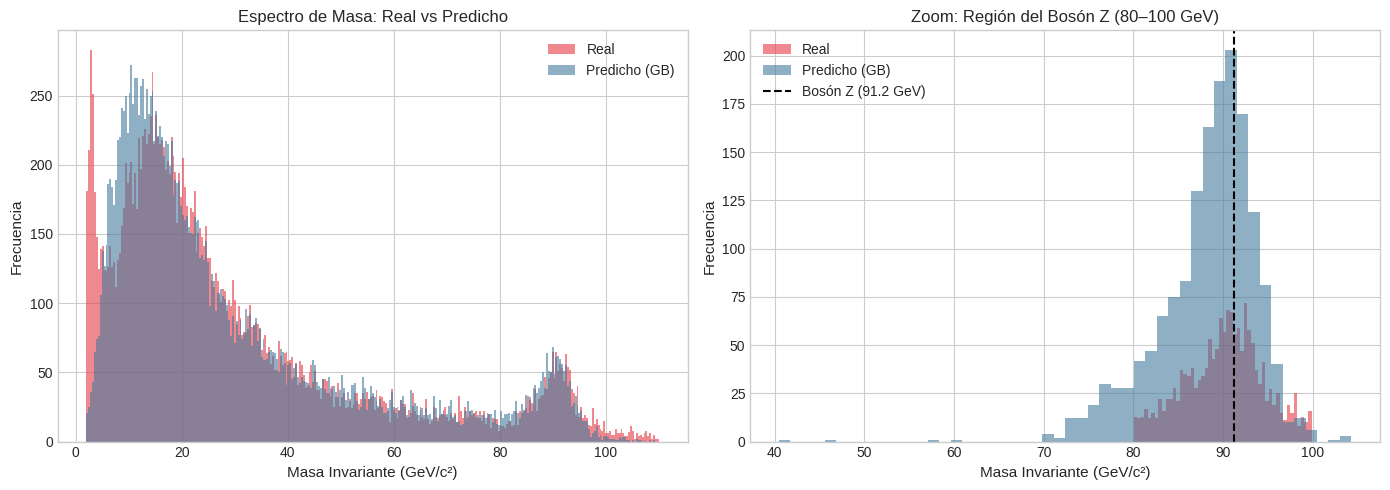

In [ ]:
# Comparar espectro real vs predicho
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = np.linspace(2, 110, 300)

axes[0].hist(y_test, bins=bins, alpha=0.6, label='Real', color=COLORS[0], edgecolor='none')
axes[0].hist(y_pred_gb, bins=bins, alpha=0.6, label='Predicho (GB)', color=COLORS[1], edgecolor='none')
axes[0].set_xlabel('Masa Invariante (GeV/c²)', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Espectro de Masa: Real vs Predicho', fontsize=12)
axes[0].legend()

# Zoom en la región del bosón Z
mask_z = (y_test > 80) & (y_test < 100)
axes[1].hist(y_test[mask_z], bins=50, alpha=0.6, label='Real', color=COLORS[0], edgecolor='none')
axes[1].hist(y_pred_gb[mask_z], bins=50, alpha=0.6, label='Predicho (GB)', color=COLORS[1], edgecolor='none')
axes[1].axvline(91.2, color='black', linestyle='--', linewidth=1.5, label='Bosón Z (91.2 GeV)')
axes[1].set_xlabel('Masa Invariante (GeV/c²)', fontsize=11)
axes[1].set_ylabel('Frecuencia', fontsize=11)
axes[1].set_title('Zoom: Región del Bosón Z (80–100 GeV)', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.savefig('espectro_real_vs_predicho.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretación física de los resultados
Los resultados del modelo deben interpretarse teniendo en cuenta que la masa invariante no es una magnitud arbitraria, sino que está vinculada físicamente con la energía y el momento de los dos electrones. Por eso, si el modelo logra aproximar bien la masa, no significa que haya descubierto una ley nueva, sino que pudo aprender a partir de los datos una relación que ya existe en la física del problema.

Desde esta perspectiva, el desempeño del modelo es valioso porque muestra hasta qué punto un algoritmo de aprendizaje automático puede reconstruir una relación física compleja sin recibir explícitamente la fórmula. En particular, los modelos no lineales resultan adecuados porque pueden captar combinaciones entre variables que no se explican bien mediante una relación lineal simple. La comparación entre los valores reales y los valores predichos permite observar si el modelo reproduce de manera razonable el comportamiento general de la masa invariante. Además, el análisis del espectro de masas permite revisar si las predicciones conservan patrones relevantes de la distribución original, como zonas de mayor concentración de eventos.

Sin embargo, esta interpretación debe ser prudente. El modelo de Machine Learning aproxima la relación entre las variables, pero no reemplaza el cálculo físico exacto cuando se dispone de la energía y de las componentes del momento necesarias. Por lo tanto, el valor principal del modelo en este trabajo está en comparar algoritmos, analizar su capacidad de aproximación y estudiar sus errores frente a una relación física conocida.

In [ ]:
E_total = df_clean["E1"] + df_clean["E2"]
px_total = df_clean["px1 "] + df_clean["px2"]
py_total = df_clean["py1"] + df_clean["py2"]
pz_total = df_clean["pz1"] + df_clean["pz2"]

M2_calc = E_total**2 - px_total**2 - py_total**2 - pz_total**2
M_calc = np.sqrt(np.maximum(M2_calc, 0))

rmse_formula = np.sqrt(mean_squared_error(df_clean["M"], M_calc))

print(f"RMSE fórmula física: {rmse_formula:.6f} GeV/c²")

RMSE fórmula física: 0.002396 GeV/c²


## 13. Conclusiones y Reflexión Final

### Síntesis de los hallazgos

Retomando las preguntas planteadas en la sección 1, los resultados obtenidos permiten responder lo siguiente:

**¿Qué tan bien aproximan los distintos algoritmos la masa invariante?** La comparación mostró una diferencia muy marcada según la capacidad del modelo para capturar relaciones no lineales. Los modelos lineales (Regresión Lineal y Ridge) explican apenas el 40% de la variabilidad de M (R² ≈ 0.40), lo cual confirma la hipótesis planteada en la sección 6: la masa invariante depende de una combinación cuadrática de energía y momento, y una relación lineal es estructuralmente insuficiente para representarla. En el otro extremo, Gradient Boosting alcanzó un R² de 0.973, con un error promedio (MAE) de apenas 2.92 GeV/c² sobre un rango de masas que va de unos pocos GeV hasta más de 100 GeV. En esta comparación empírica, Gradient Boosting fue el modelo con mejor desempeño, lo que muestra que los métodos de ensamble basados en árboles resultaron especialmente adecuados para este conjunto de datos y esta forma de evaluación.

**¿Qué variables tienen mayor poder predictivo?** El análisis de importancia de features mostró que las variables de momento transversal (pt1, pt2) y las componentes de momento (pz1, pz2), junto con la energía (E1, E2), son las que más aporta el modelo. Esto es consistente con la física del problema: son justamente esas magnitudes las que entran en la fórmula de masa invariante, recordando que es:
$$M = \sqrt{(E_1 + E_2)^2 - |\vec{p}_1 + \vec{p}_2|^2}$$

**¿Se pueden identificar las resonancias físicas conocidas?** El espectro de masas predicho reproduce razonablemente bien la forma general del espectro real, incluyendo la acumulación de eventos en la región del bosón Z (~91 GeV). Esto sugiere que el modelo no solo minimiza el error promedio, sino que conserva parte de la estructura física subyacente en los datos, aunque suaviza picos angostos como J/ψ o ϒ, donde el error relativo es proporcionalmente mayor.



### Limitaciones del trabajo

- El MAPE (23.67%) es considerablemente más alto que lo que sugiere el R². Esto ocurre porque los eventos con masa invariante cercana a 0 GeV producen errores relativos muy grandes aunque el error absoluto sea pequeño, lo cual es una limitación conocida de esa métrica en este tipo de distribución.
- El dataset corresponde a un único experimento (CMS) y a un conjunto acotado de runs; no se evaluó la capacidad del modelo de generalizar a datos de otras campañas de toma de datos.


### Propuestas de trabajo futuro

A partir de estos resultados y limitaciones, proponemos los siguientes caminos para extender este trabajo:

1. **Repetir la búsqueda de hiperparámetros**, usando una porción mayor del conjunto de entrenamiento (o su totalidad), más folds de validación cruzada y mayor número de *trials*, para verificar si efectivamente es posible superar el modelo base.
2. **Probar redes neuronales (MLP) u otro modelo más adelante en CEIA**, dado que la relación entre las variables y la masa invariante es altamente no lineal; un perceptrón multicapa podría capturar interacciones que el ensamble de árboles aproxima solo parcialmente.
3. **Combinar modelos mediante stacking o ensambles heterogéneos** (por ejemplo, Random Forest + Gradient Boosting), para evaluar si una combinación de predictores reduce aún más el error.
4. **Explorar enfoques *physics-informed***, donde la fórmula física de masa invariante se incorpore como restricción o como feature adicional, en lugar de dejar que el modelo la aprenda completamente desde cero.


### Reflexión de cierre

Este trabajo permitió comparar de manera empírica distintos algoritmos de regresión sobre un problema con fundamento físico claro, lo cual nos brindó una forma concreta de validar si los resultados del modelo tenían sentido más allá de las métricas numéricas. El hallazgo central —que los modelos basados en árboles, y en particular Gradient Boosting, logran aproximar muy bien una relación física no lineal sin recibir la fórmula explícitamente— refuerza la idea de que el machine learning puede ser una herramienta complementaria valiosa en física de partículas, útil por ejemplo para validación cruzada de mediciones o reconstrucción de eventos parciales, pero no un reemplazo del cálculo físico exacto cuando los datos necesarios están disponibles. El proceso también dejó como aprendizaje metodológico que cada etapa del pipeline —incluida la optimización de hiperparámetros— debe evaluarse y reportarse con el mismo rigor que el modelo final, incluso cuando el resultado no es el esperado.



